nimi

## Business understanding: Riikka

## Part 1:

### Data understanding: Riikka

In [1]:
import pandas as pd

df = pd.read_csv('datasets/drone_cust_locations.csv', sep=';')
df

,clientid,x,y
0,1,622.771572,164.857623
1,2,416.357298,630.193634
2,3,292.735020,567.333231
3,4,737.211288,166.225676
4,5,540.475375,682.912298
...,...,...,...
5951,5952,832.857394,616.861410
5952,5953,242.734500,490.325092
5953,5954,108.690847,758.833921
5954,5955,803.251074,430.740623


<Axes: xlabel='x', ylabel='y'>

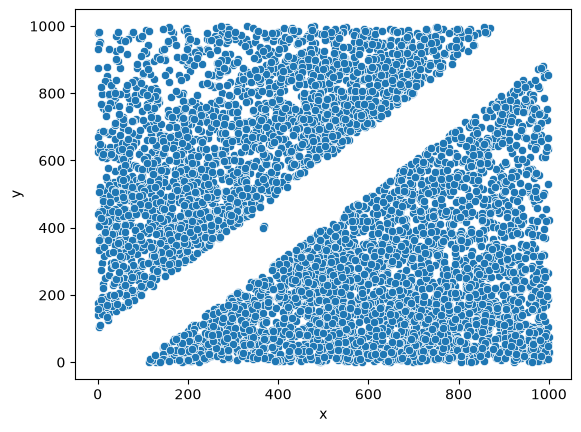

In [2]:
import seaborn as sns

sns.scatterplot(data=df, x="x", y="y")

### Data preparation: Sandra

In [3]:
df = df.drop(columns='clientid')

### Modeling:

#### K-Means: Sandra

In [4]:
from sklearn.cluster import KMeans
import time
tic = time.perf_counter()

model = KMeans(init='random', n_clusters=3, random_state=42)
model.fit(df)

toc = time.perf_counter()

print(f"{toc - tic:0.4f} seconds")


2.5025 seconds


In [5]:
labels = model.labels_
labels

array([0, 2, 1, ..., 1, 0, 0], shape=(5956,), dtype=int32)

In [6]:
centers = pd.DataFrame(model.cluster_centers_, columns=['x', 'y'])

In [7]:
new_df = pd.DataFrame(labels, columns=['depot'])
new_df

,depot
0,0
1,2
2,1
3,0
4,2
...,...
5951,2
5952,1
5953,1
5954,0


In [8]:
combined = pd.concat([df, new_df], axis=1)
combined.head(10)

,x,y,depot
0,622.771572,164.857623,0
1,416.357298,630.193634,2
2,292.735020,567.333231,1
3,737.211288,166.225676,0
4,540.475375,682.912298,2
5,535.469492,318.439661,0
6,640.380050,870.833221,2
7,235.772075,359.048203,1
8,481.896884,661.491838,2
9,730.032789,312.177817,0


<Axes: xlabel='x', ylabel='y'>

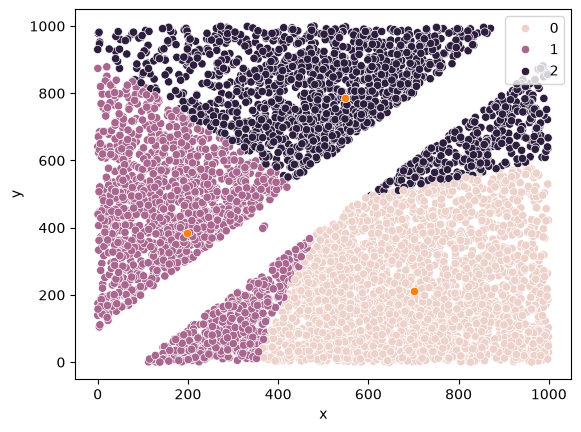

In [9]:
ax = sns.scatterplot(data=combined, x="x", y="y", hue="depot")
sns.scatterplot(data=centers, x="x", y="y", ax=ax)

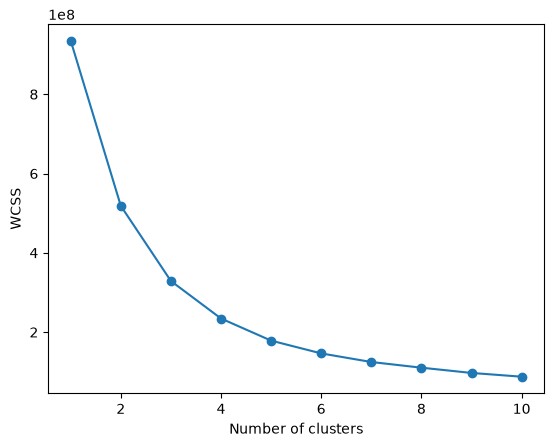

In [10]:
import matplotlib.pyplot as plt

wcss = []
for i in range(1,11):
    model = KMeans(init='random', n_clusters=i, random_state=42).fit(df)
    wcss.append(model.inertia_)
    
plt.plot(range(1,11), wcss, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [11]:
from sklearn.metrics import silhouette_score

print('Silhouette score = %.2f' % silhouette_score(combined, labels))

Silhouette score = 0.42


scoret: 

k=4 tulos:0.40 (paras),0.2115 seconds

k=3 tulos: 0.42, 0.1946 seconds

k=10 tulos: 0.37, 0.2517 seconds, 0.2542 seconds

k=5 tulos: 0.42, 0.1946 seconds

#### Hierarkinen: Nur

In [12]:
from sklearn.cluster import AgglomerativeClustering

n_depots = 3
model = AgglomerativeClustering(n_clusters=n_depots)
labels = model.fit_predict(df)
df['depot_hier'] = labels
#df.head(20)

In [13]:
from sklearn.metrics import silhouette_score

model = AgglomerativeClustering(n_clusters=3).fit(df)
labels = model.labels_
print('Silhouette score = %.2f' % silhouette_score(df, labels))

Silhouette score = 0.41


scoret: 

k=4 tulos: 0.36

k=3 tulos: 0.41

k=10 tulos: 0.34

k=5 tulos: 0.37

<Axes: xlabel='x', ylabel='y'>

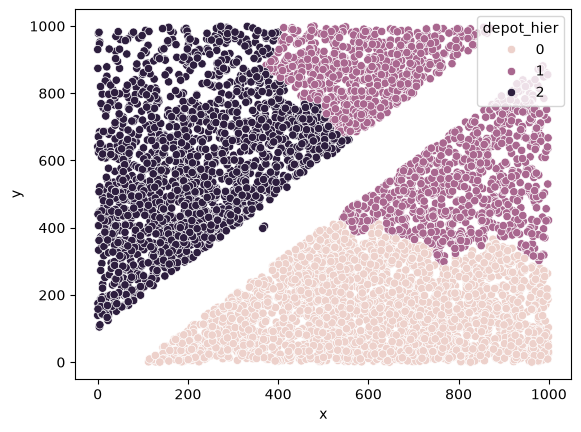

In [14]:
sns.scatterplot(data=df, x="x", y="y", hue="depot_hier")

In [15]:
# kakkonen enemmän orgaanisen näköinen eli jakoi joen kohdalta puoliksi oikein, vertaa ykköseen jonka klusterit jakautuu joen molemmille puolille epätasaisesti

In [16]:
# lisää ss scatterplot k-arvoilla 4 (sekä hierarkinen että k-means)

### Evaluation: Nur

In [17]:
# vertailu

## Part 2:

### Data understanding: Riikka

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

df = pd.read_csv('datasets/drone_prod_groups.csv', sep=',')
df

,ID,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,...,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
1,2,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,1,1,1,1,1
2,3,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1
3,4,1,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,1
4,5,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
99996,99997,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
99997,99998,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,1,0,0
99998,99999,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,1


In [19]:
df.describe()

,ID,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,...,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
count,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,0.109980,0.13098,0.032710,0.035850,0.104590,0.02952,0.134990,0.16179,0.198530,...,0.108480,0.159710,0.013390,0.145570,0.118800,0.131000,0.05618,0.121660,0.206260,0.147980
std,28867.657797,0.312866,0.33738,0.177877,0.185917,0.306026,0.16926,0.341715,0.36826,0.398895,...,0.310987,0.366339,0.114938,0.352676,0.323555,0.337402,0.23027,0.326894,0.404621,0.355082
min,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
max,100000.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000


### Data preparation: Anni

In [20]:
# drop id
df = df.drop(columns='ID')

# 0=false ja 1=true
df = df.astype(bool)
df

,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,Prod10,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True
1,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,True,True,True,True,True
2,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True
3,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True
4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
99996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
99997,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False
99998,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True


### Modeling: Anni

In [21]:
# find frequent itemsets
frequent_itemsets = apriori(df, min_support=0.03, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.10998,frozenset({Prod1})
1,0.13098,frozenset({ Prod2})
2,0.03271,frozenset({ Prod3})
3,0.03585,frozenset({ Prod4})
4,0.10459,frozenset({ Prod5})
5,0.13499,frozenset({ Prod7})
6,0.16179,frozenset({ Prod8})
7,0.19853,frozenset({ Prod9})
8,0.09336,frozenset({ Prod10})
9,0.10848,frozenset({ Prod11})


In [22]:
# generate association rules

rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.55)

# sort in descending order of confidence
rules = rules.sort_values(by='confidence', ascending=False)

rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1,frozenset({ Prod15}),frozenset({ Prod9}),0.11880,0.19853,0.11145,0.938131,4.725388,1.0,0.087865,12.954372,0.894663,0.541335,0.922806,0.749754
3,frozenset({ Prod20}),frozenset({ Prod19}),0.14798,0.20626,0.13476,0.910664,4.415125,1.0,0.104238,8.884845,0.907849,0.613997,0.887449,0.782007
5,"frozenset({ Prod20, Prod9})",frozenset({ Prod19}),0.03676,0.20626,0.03345,0.909956,4.411696,1.0,0.025868,8.815070,0.802842,0.159613,0.886558,0.536065
6,"frozenset({ Prod9, Prod19})",frozenset({ Prod20}),0.04996,0.14798,0.03345,0.669536,4.524501,1.0,0.026057,2.578251,0.819946,0.203356,0.612140,0.447790
4,frozenset({ Prod19}),frozenset({ Prod20}),0.20626,0.14798,0.13476,0.653350,4.415125,1.0,0.104238,2.457869,0.974508,0.613997,0.593144,0.782007
0,frozenset({ Prod5}),frozenset({ Prod12}),0.10459,0.15971,0.06683,0.638971,4.000822,1.0,0.050126,2.327488,0.837662,0.338431,0.570352,0.528709
2,frozenset({ Prod9}),frozenset({ Prod15}),0.19853,0.11880,0.11145,0.561376,4.725388,1.0,0.087865,2.009011,0.983664,0.541335,0.502243,0.749754


In [23]:
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=4)

# sort in descending order of lift
rules = rules.sort_values(by='lift', ascending=False)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3,frozenset({ Prod9}),frozenset({ Prod15}),0.19853,0.11880,0.11145,0.561376,4.725388,1.0,0.087865,2.009011,0.983664,0.541335,0.502243,0.749754
2,frozenset({ Prod15}),frozenset({ Prod9}),0.11880,0.19853,0.11145,0.938131,4.725388,1.0,0.087865,12.954372,0.894663,0.541335,0.922806,0.749754
8,frozenset({ Prod20}),"frozenset({ Prod9, Prod19})",0.14798,0.04996,0.03345,0.226044,4.524501,1.0,0.026057,1.227512,0.914276,0.203356,0.185344,0.447790
7,"frozenset({ Prod9, Prod19})",frozenset({ Prod20}),0.04996,0.14798,0.03345,0.669536,4.524501,1.0,0.026057,2.578251,0.819946,0.203356,0.612140,0.447790
5,frozenset({ Prod19}),frozenset({ Prod20}),0.20626,0.14798,0.13476,0.653350,4.415125,1.0,0.104238,2.457869,0.974508,0.613997,0.593144,0.782007
4,frozenset({ Prod20}),frozenset({ Prod19}),0.14798,0.20626,0.13476,0.910664,4.415125,1.0,0.104238,8.884845,0.907849,0.613997,0.887449,0.782007
6,"frozenset({ Prod20, Prod9})",frozenset({ Prod19}),0.03676,0.20626,0.03345,0.909956,4.411696,1.0,0.025868,8.815070,0.802842,0.159613,0.886558,0.536065
9,frozenset({ Prod19}),"frozenset({ Prod20, Prod9})",0.20626,0.03676,0.03345,0.162174,4.411696,1.0,0.025868,1.149690,0.974286,0.159613,0.130200,0.536065
1,frozenset({ Prod5}),frozenset({ Prod12}),0.10459,0.15971,0.06683,0.638971,4.000822,1.0,0.050126,2.327488,0.837662,0.338431,0.570352,0.528709
0,frozenset({ Prod12}),frozenset({ Prod5}),0.15971,0.10459,0.06683,0.418446,4.000822,1.0,0.050126,1.539685,0.892610,0.338431,0.350516,0.528709


johtopäätökset: confidence tuotekategorioiden välillä ei mene molempiin suntiin eli todennäköisyydet vaihtelee vaikka kyseessä olisi samat kategoriat (esim. sarakkeet 3 ja 4)
confidence yli 50 prossaa (50)
lift on aina > 4

min_support on matala, koska dataa on paljon ja esiintyvyys siksi pienempi


### Evaluation: Anni

In [24]:
# tähän recommendation

## Deployment: Riikka
